# **Text Classification**

---






In [3]:
# Run this cell if you use Colab
# from google.colab import drive
# drive.mount('/content/drive')

Load and read in dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_pickle('/content/drive/MyDrive/CPE393/consumer_complaint_dataset.data', compression='gzip')

In [5]:
df.head()

,topic,input
0,Debt collection,transworld systems inc. \nis trying to collect...
1,"Credit reporting, credit repair services, or o...",I would like to request the suppression of the...
2,Debt collection,"Over the past 2 weeks, I have been receiving e..."
3,"Credit reporting, credit repair services, or o...",I HAD FILED WITH CFPB ON XX/XX/XXXX19 TO HAVE ...
4,"Credit reporting, credit repair services, or o...",I have several accounts that the balance is in...


## Distribution

In [6]:
pd.crosstab(df.topic, columns="Count").sort_values(by='Count', ascending=False)

col_0,Count
topic,
"Credit reporting, credit repair services, or other personal consumer reports",145090
Debt collection,106946
Mortgage,61581
Credit card or prepaid card,32144
Credit reporting,31588
Student loan,25083
Checking or savings account,19153
Credit card,18838
Bank account or service,14885


## Group Labels

In [7]:
df.loc[df['topic']=='Credit reporting', 'topic'] = 'Credit reporting, credit repair services, or other personal consumer reports'
df.loc[df['topic']=='Credit card', 'topic'] = 'Credit card or prepaid card'
df.loc[df['topic']=='Prepaid card', 'topic'] = 'Credit card or prepaid card'
df.loc[df['topic']=='Payday load', 'topic'] = 'Payday loan, title loan, or personal loan'
df.loc[df['topic']=='Virtual currency', 'topic'] = 'Money transfer, virtual currency, or money service'
df.loc[df['topic']=='Money transfers', 'topic'] = 'Money transfer, virtual currency, or money service'
df = df[df['topic'] != 'Other financial service']

## Labels after grouping

In [8]:
pd.crosstab(df.topic, columns="Count").sort_values(by='Count', ascending=False)

col_0,Count
topic,
"Credit reporting, credit repair services, or other personal consumer reports",176678
Debt collection,106946
Mortgage,61581
Credit card or prepaid card,52432
Student loan,25083
Checking or savings account,19153
Bank account or service,14885
Consumer Loan,9473
"Money transfer, virtual currency, or money service",9378


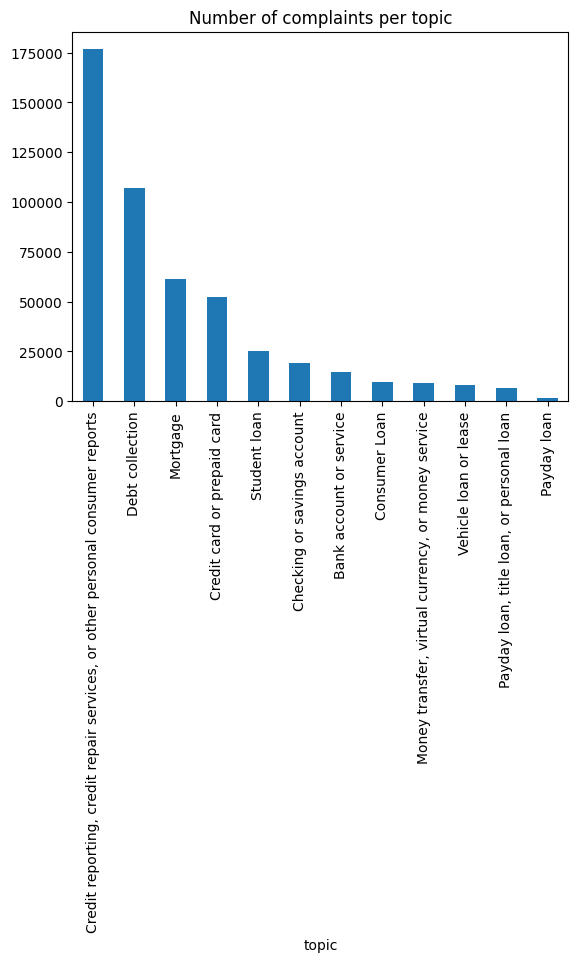

In [9]:
df['topic'].value_counts().sort_values(ascending=False).plot(kind='bar',title='Number of complaints per topic')
plt.show()

## Choose Target Column

In [10]:
df = df.groupby('topic', group_keys=False).apply(lambda x: x.sample(1700, random_state=42))
print(df['topic'].value_counts())

topic
Bank account or service                                                         1700
Checking or savings account                                                     1700
Consumer Loan                                                                   1700
Credit card or prepaid card                                                     1700
Credit reporting, credit repair services, or other personal consumer reports    1700
Debt collection                                                                 1700
Money transfer, virtual currency, or money service                              1700
Mortgage                                                                        1700
Payday loan                                                                     1700
Payday loan, title loan, or personal loan                                       1700
Student loan                                                                    1700
Vehicle loan or lease                                      

/tmp/ipython-input-3063096750.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('topic', group_keys=False).apply(lambda x: x.sample(1700, random_state=42))


In [11]:
df.head()

,topic,input
341078,Bank account or service,"On XXXX XXXX, 2016 and XXXX XXXX, 2016 Capital..."
265590,Bank account or service,I PURCHASED A {$20000.00} CD ) CERTIFICATE OF ...
243488,Bank account or service,I currently bank with Wells Fargo. For years t...
300967,Bank account or service,While signing up for a checking account at Reg...
213171,Bank account or service,XXXX 2011 my purse was stolen out of my car an...


In [12]:
df.shape

(20400, 2)

## Clean Data

In [13]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
from nltk.corpus import stopwords
stopwords.words('english')[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [15]:
import re

REPLACE_BY_SPLACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
STOPWORDS = set(stopwords.words('english'))

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:3: SyntaxWarning: invalid escape sequence '\['
/tmp/ipython-input-3808894635.py:3: SyntaxWarning: invalid escape sequence '\['
  REPLACE_BY_SPLACE_RE = re.compile('[/(){}\[\]\|@,;]')


## Function to clean text

In [16]:
def clean_text(text):
  text = text.lower()
  text = REPLACE_BY_SPLACE_RE.sub(' ', text)
  text = BAD_SYMBOLS_RE.sub('', text)
  text = text.replace('x', '')
  text = ' '.join(word for word in text.split() if word not in STOPWORDS)
  return text

In [17]:
df['input'] = df['input'].apply(clean_text)

df['input'] = df['input'].str.replace('\d+','')

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3921887566.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['input'] = df['input'].str.replace('\d+','')


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['topic'])
num_classes = len(le.classes_)
print("Number of classes:", num_classes)

Number of classes: 12


# Modeling
1. Vectorize input consumer complaints
2. Limit dataset to top 50000 words
3. Set max number of words in each complaint to 250

## Train Tokenizer

```
from keras.preprocessing.text import Tokenizer

MAX_NB_WORDS = 50000

MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words = MAX_NB_WORDS,
                      filters = '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~',
                      lower=True)
tokenizer.fit_on_texts(df['input'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.'%len(word_index))
```
**แก้ error**


**1. from tensorflow.keras.preprocessing.text import Tokenizer หรือใช้ from tensorflow.keras.preprocessing.sequence import pad_sequences**

**2. filters = r'!"#$%&()*+,-./:;<=>?@[\]^_`{|}~' (เติมตัว r)**

In [24]:
!pip install keras

In [28]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
MAX_NUM_WORDS = 50000
MAX_SEQUENCE_LENGTH = 250

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS,
                      filters = '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~',
                      lower=True)
tokenizer.fit_on_texts(df['input'].values)
X_seq = tokenizer.texts_to_sequences(df['input'].values)
X = pad_sequences(X_seq, maxlen=MAX_SEQUENCE_LENGTH)

<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:7: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-2232912560.py:7: SyntaxWarning: invalid escape sequence '\]'
  filters = '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~',


In [30]:
from tensorflow.keras.utils import to_categorical
Y = to_categorical(df['label'], num_classes=num_classes)

## Split train/test

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
labels = np.argmax(Y, axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (16320, 250)
X_test: (4080, 250)
Y_train: (16320, 12)
Y_test: (4080, 12)


## Construct LSTM Text Classifier

In [38]:
from keras.models import Sequential
from keras.layers import Embedding, SpatialDropout1D, LSTM, Dense
from keras.callbacks import EarlyStopping

MAX_NB_WORDS = 50000
EMBEDDING_DIM = 100

# Initialize the model
model = Sequential()  # Create a Sequential model

# Embedding Layer
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))

# SpatialDropout1D Layer
# Drops entire 1D feature maps (embedding dimensions) randomly to prevent overfitting.
# Helps the model generalize better and not rely too much on specific embedding dimensions.
model.add(SpatialDropout1D(0.2))

# LSTM Layer
# LSTM (Long Short-Term Memory) is a type of RNN (Recurrent Neural Network)
# It captures sequential dependencies in text data (context from previous words).
# 64 units = dimensionality of the LSTM output space
# dropout = 0.3: dropout applied to input connections to prevent overfitting
# recurrent_dropout = 0.3: dropout applied to recurrent (hidden state) connections
model.add(LSTM(64, dropout=0.3, recurrent_dropout=0.3))

# Dense Output Layer
# Fully connected layer with 12 output units (for 12 target classes)
# Softmax activation converts the outputs into probabilities that sum to 1
model.add(Dense(12, activation='softmax'))

# Model Compilation
# loss = 'categorical_crossentropy': suitable for multi-class classification
# optimizer = 'adam': adaptive learning rate optimizer (works well for most problems)
# metrics = ['accuracy']: to track accuracy during training and evaluation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training Configuration
epochs = 35           # Number of passes through the entire training dataset
batch_size = 128      # Number of samples processed before model updates weights

# Model Training
history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, min_delta=0.00001)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 100s 824ms/step - accuracy: 0.1415 - loss: 2.3887 - val_accuracy: 0.2163 - val_loss: 1.9451
Epoch 2/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 711ms/step - accuracy: 0.2707 - loss: 1.9066 - val_accuracy: 0.3395 - val_loss: 1.8445
Epoch 3/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 665ms/step - accuracy: 0.3586 - loss: 1.7497 - val_accuracy: 0.3732 - val_loss: 1.7297
Epoch 4/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 666ms/step - accuracy: 0.4362 - loss: 1.5478 - val_accuracy: 0.4669 - val_loss: 1.5285
Epoch 5/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 83s 671ms/step - accuracy: 0.5106 - loss: 1.3768 - val_accuracy: 0.4951 - val_loss: 1.4524
Epoch 6/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 668ms/step - accuracy: 0.5797 - loss: 1.2098 - val_accuracy: 0.5172 - val_loss: 1.4389
Epoch 7/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 83s 681ms/step - accuracy: 0.6131 - loss: 1.1176 - val_accuracy: 0.5460 - val_loss: 1.3461
Epoch 8/35
115/115 ━━━━━━━━━━━━━━━━━━━━ 78s 676ms/step - accuracy: 0.6447 - loss: 

## Evaluate the model

In [39]:
acc = model.evaluate(X_test, Y_test)
print('Test set \n\tLoss: {:0.3f}\n\tAccuracy: {:0.3f}'.format(acc[0], acc[1]))

128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.5834 - loss: 1.3315
Test set 
	Loss: 1.344
	Accuracy: 0.580


## Loss

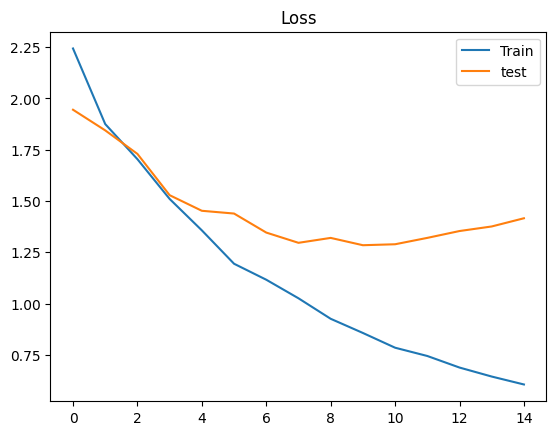

In [40]:
plt.title('Loss')
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

## Accuracy

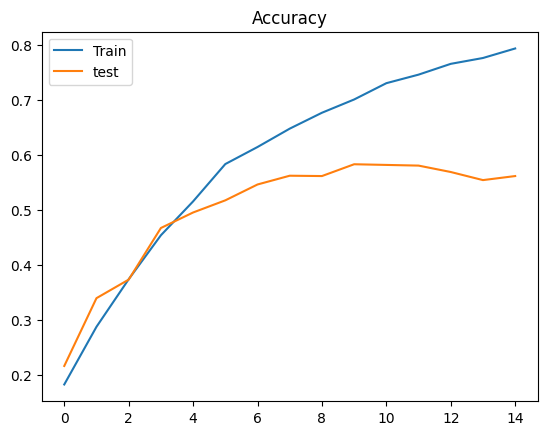

In [41]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

## Confusion Matrix

In [42]:
labels = pd.get_dummies(df['topic']).columns
list(labels)

['Bank account or service',
 'Checking or savings account',
 'Consumer Loan',
 'Credit card or prepaid card',
 'Credit reporting, credit repair services, or other personal consumer reports',
 'Debt collection',
 'Money transfer, virtual currency, or money service',
 'Mortgage',
 'Payday loan',
 'Payday loan, title loan, or personal loan',
 'Student loan',
 'Vehicle loan or lease']

**ไม่เกิด error เกี่ยวกับ shape เนื่องจากนำทุก class มาเทรนและทดสอบ**

In [43]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)

# confusion_matrix(Y_test.argmax(axis=1),
#                  y_pred.argmax(axis=1))

pd.DataFrame(confusion_matrix(Y_test.argmax(axis=1),
                              y_pred.argmax(axis=1)),
             index=labels, columns=labels)

128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step


,Bank account or service,Checking or savings account,Consumer Loan,Credit card or prepaid card,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,"Money transfer, virtual currency, or money service",Mortgage,Payday loan,"Payday loan, title loan, or personal loan",Student loan,Vehicle loan or lease
Bank account or service,86,174,4,16,5,5,28,3,6,11,1,1
Checking or savings account,81,198,1,10,3,1,29,5,6,4,1,1
Consumer Loan,1,4,95,8,15,10,4,7,31,43,2,120
Credit card or prepaid card,13,37,6,215,25,8,13,3,2,11,2,5
"Credit reporting, credit repair services, or other personal consumer reports",2,5,15,22,225,34,1,6,4,1,15,10
Debt collection,5,4,12,8,28,216,1,10,17,24,9,6
"Money transfer, virtual currency, or money service",16,35,3,10,4,5,252,4,5,3,1,2
Mortgage,3,3,12,3,4,4,2,269,9,25,1,5
Payday loan,7,3,5,1,6,24,2,1,231,58,0,2
"Payday loan, title loan, or personal loan",6,10,44,8,15,12,1,7,90,123,4,20


## Classification Report

In [44]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_true=Y_test.argmax(axis=1),
                            y_pred=y_pred.argmax(axis=1)))

128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step
              precision    recall  f1-score   support

           0       0.39      0.25      0.31       340
           1       0.42      0.58      0.48       340
           2       0.30      0.28      0.29       340
           3       0.70      0.63      0.67       340
           4       0.65      0.66      0.66       340
           5       0.65      0.64      0.64       340
           6       0.75      0.74      0.75       340
           7       0.84      0.79      0.81       340
           8       0.56      0.68      0.61       340
           9       0.36      0.36      0.36       340
          10       0.89      0.87      0.88       340
          11       0.48      0.47      0.47       340

    accuracy                           0.58      4080
   macro avg       0.58      0.58      0.58      4080
weighted avg       0.58      0.58      0.58      4080



## Test using new complaints


In [45]:
import numpy as np
new_complaint = ['I am a victim of identity theft']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = model.predict(padded)
labels=pd.get_dummies(df['topic']).columns.values

print(pred, labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[0.016336   0.0328017  0.06737822 0.0533501  0.3019013  0.38719794
  0.01072937 0.00865279 0.03170568 0.03504975 0.01909362 0.03580349]] Debt collection
